In [240]:
# !pip install pandas numpy matplotlib seaborn nltk scikit-learn wordcloud networkx folium tqdm

In [241]:
# imports
import json
import re
from ast import literal_eval
from datetime import datetime
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import networkx as nx
import pycountry

# optional for maps
import folium

In [242]:
# Loading Data

df = pd.read_csv("jobs_raw.csv", dtype=str)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
df.head()


Dataset Shape: (10836, 34)
Total Records: 10836
Total Columns: 34


,id,site,job_url,job_url_direct,title,company,location,date_posted,job_type,salary_source,interval,min_amount,max_amount,currency,is_remote,job_level,job_function,listing_type,emails,description,company_industry,company_url,company_logo,company_url_direct,company_addresses,company_num_employees,company_revenue,company_description,skills,experience_range,company_rating,company_reviews_count,vacancy_count,work_from_home_type
0,in-9c1190c31ff7b1fe,indeed,https://in.indeed.com/viewjob?jk=9c1190c31ff7b1fe,https://jobs.smartrecruiters.com/NielsenIQ/744000097425845-director-global-thought-leadership-an...,Director - Global Thought Leadership Analysis & Analytics,NielsenIQ,"MH, IN",2025-12-07,fulltime,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,"**Job Description** **Summary**\n\n\nAs the Global Thought Leader: Analytics \& Analysis, this r...",NaN,https://in.indeed.com/cmp/Nielseniq-6,https://d2q79iu7y748jz.cloudfront.net/s/_squarelogo/256x256/b36ad0277649777a7e45862e1349e96b,https://nielseniq.com/global/en/,NaN,"10,000+",NaN,"NielsenIQ is the industry leader in global measurement and data analytics, and the most trusted ...",NaN,NaN,NaN,NaN,NaN,NaN
1,in-a71ee5a36519ef0c,indeed,https://in.indeed.com/viewjob?jk=a71ee5a36519ef0c,http://in.indeed.com/job/ai-engineer-a71ee5a36519ef0c,AI Engineer,SB Infowaves,"KA, IN",2025-12-07,fulltime,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,We are hiring AI Engineer\n\n**About the Role**\n\nWe are looking for an **AI Engineer** with ha...,NaN,https://in.indeed.com/cmp/Sb-Infowaves,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,in-b7f02a2275d86cf4,indeed,https://in.indeed.com/viewjob?jk=b7f02a2275d86cf4,https://grnh.se/t2ex0tud3us,Senior Data Scientist,Careers at Tide,"DL, IN",2025-12-07,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,talent@tide.co,### **ABOUT TIDE**\n\n\n\nAt Tide we help SMEs save time (and money) in the running of their bus...,NaN,https://in.indeed.com/cmp/Careers-At-Tide,NaN,https://www.tide.co/careers/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,in-fa22f4c1c2d81b63,indeed,https://in.indeed.com/viewjob?jk=fa22f4c1c2d81b63,https://grnh.se/r36i21mb3us,Senior Data Scientist,Careers at Tide,"TS, IN",2025-12-07,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,talent@tide.co,### **ABOUT TIDE**\n\n\n\nAt Tide we help SMEs save time (and money) in the running of their bus...,NaN,https://in.indeed.com/cmp/Careers-At-Tide,NaN,https://www.tide.co/careers/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,in-1dd70c5f2ee464bb,indeed,https://in.indeed.com/viewjob?jk=1dd70c5f2ee464bb,https://grnh.se/01cwz6c93us,Senior Data Scientist,Careers at Tide,"KA, IN",2025-12-07,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,talent@tide.co,### **ABOUT TIDE**\n\n\n\nAt Tide we help SMEs save time (and money) in the running of their bus...,NaN,https://in.indeed.com/cmp/Careers-At-Tide,NaN,https://www.tide.co/careers/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [243]:
# Checking Null Values
df.isna().sum()

id                           0
site                         0
job_url                      0
job_url_direct            6476
title                        0
company                     27
location                   759
date_posted                256
job_type                  7955
salary_source            10836
interval                 10836
min_amount               10836
max_amount               10836
currency                 10836
is_remote                    0
job_level                10836
job_function             10836
listing_type             10836
emails                   10360
description               6476
company_industry         10155
company_url                 12
company_logo              7995
company_url_direct        7904
company_addresses         8114
company_num_employees     7978
company_revenue           8291
company_description       8696
skills                   10836
experience_range         10836
company_rating           10836
company_reviews_count    10836
vacancy_

In [244]:

# Dropping null values
df = df.drop(columns=['salary_source', 'interval', 'min_amount', 'max_amount', 'currency', 'job_level', 'job_function', 'listing_type', 'interval', 'emails', 
                      'vacancy_count', 'work_from_home_type', 'company_url', 'company_logo', 'company_logo', 'company_url_direct', 'company_addresses', 'company_num_employees', 'job_url_direct',
                      'company_revenue','company_description','company_rating','company_reviews_count', 'experience_range', 'skills', 'company_industry'])

df.isna().sum()

id                0
site              0
job_url           0
title             0
company          27
location        759
date_posted     256
job_type       7955
is_remote         0
description    6476
dtype: int64

In [245]:
# Basic Cleaning

# strip whitespace from column names and values
df.columns=df.columns.str.strip()
df = df.applymap(lambda x:x.strip() if isinstance(x, str) else x)

# parse date columns
for col in ['posted_date', 'scraped_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors = 'coerce')

# convert skill_count to numeric
if 'skill_count' in df.columns:
    df['skill_count'] = pd.to_numeric(df['skill_count'], errors = 'coerce')
    

# filling null values
df['company'] = df['company'].fillna('Unknown')

In [246]:
# Spliting location into city, state, country (handle codes like MH, IN)
STATE_CODE_MAP = {
    "KA": "Karnataka",
    "TS": "Telangana",
    "MH": "Maharashtra",
    "TN": "Tamil Nadu",
    "HR": "Haryana",
    "UP": "Uttar Pradesh",
    "DL": "Delhi",
    "WB": "West Bengal",
}

def split_location(loc):
    if pd.isna(loc):
        return pd.Series([np.nan, np.nan, np.nan])
    
    s = str(loc).strip()

    # Pattern: "KA, IN"
    m = re.match(r'^([A-Za-z]{2,3})\s*,\s*([A-Za-z]{2})$', s)
    if m:
        code, country = m.groups()
        state_full = STATE_CODE_MAP.get(code.upper(), code.title())
        country_full = "India" if country.upper() == "IN" else country.title()
        return pd.Series([np.nan, state_full, country_full])
    
    parts = [p.strip() for p in s.split(',')]
    if len(parts) == 1:
        return pd.Series([parts[0].title(), np.nan, np.nan])
    if len(parts) == 2:
        city, country = parts
        return pd.Series([city.title(), np.nan, country.title()])
    
    city, state, country = parts[0], parts[1], parts[2]
    return pd.Series([city.title(), state.title(), country.title()])

df[['city', 'state', 'country']] = df['location'].apply(split_location)


In [247]:
# Filling missing city/state 

CITY_STATE_MAP = {
    "Bangalore": "Karnataka",
    "Hyderabad": "Telangana",
    "Pune": "Maharashtra",
    "Chennai": "Tamil Nadu",
    "Mumbai": "Maharashtra",
    "Gurugram": "Haryana",
    "Noida": "Uttar Pradesh",
    "Delhi": "Delhi",
    "Kolkata": "West Bengal"
}

STATE_NAME_MAP = {
    "ka": "Karnataka",
    "ts": "Telangana",
    "mh": "Maharashtra",
    "tn": "Tamil Nadu",
    "hr": "Haryana",
    "up": "Uttar Pradesh",
    "dl": "Delhi",
    "wb": "West Bengal",
    "ap": "Andhra Pradesh",
    "ch": "Tamil Nadu",
    "gj": "Gujarat",
    "kl": "Kerala",
    "mp": "Madhya Pradesh",
    "or": "Odisha",
    "psd": "Telangana",
    "pb": "Punjab",
    "rj": "Rajasthan",
    "ct": "Chhattisgarh",
    "ga": "Goa",
    "as": "Assam"
}

def fill_city_state(row):
    # Ensure country
    if pd.isna(row['country']) or str(row['country']).strip().lower() in ['in', 'india', '']:
        row['country'] = 'India'
    
    # Fill only *missing* city/state from location
    if (pd.isna(row['city']) or pd.isna(row['state'])) and pd.notna(row['location']):
        loc_city = row['location'].split(',')[0].strip().title()
        
        if pd.isna(row['city']):
            row['city'] = loc_city
        
        if pd.isna(row['state']):
            mapped_state = CITY_STATE_MAP.get(loc_city)
            if mapped_state:
                row['state'] = mapped_state

    # Normalize/expand state
    if pd.notna(row['state']):
        st = str(row['state']).strip()
        row['state'] = STATE_NAME_MAP.get(st.lower(), st.title())
    
    return row

df = df.apply(fill_city_state, axis=1)
df['state'] = df['state'].fillna('Unknown')

In [248]:
# Inspecting unique states (no TypeError)
print("✅ State cleaned successfully!\n")
print("Unique states:", sorted(df['state'].dropna().unique()))
print("\nTotal records:", len(df))
print("\nState distribution:\n", df['state'].value_counts(dropna=False))

✅ State cleaned successfully!

Unique states: ['Andhra Pradesh', 'Assam', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Tripura', 'Unknown', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Total records: 10836

State distribution:
 state
Maharashtra       2410
Karnataka         1702
Telangana         1347
Tamil Nadu        1192
Delhi             1076
Haryana            977
Unknown            853
Uttar Pradesh      626
West Bengal        533
Gujarat             34
Kerala              26
Punjab              15
Madhya Pradesh      10
Andhra Pradesh       9
Rajasthan            7
Odisha               6
Chhattisgarh         4
Uttarakhand          3
Chandigarh           3
Tripura              1
Assam                1
Goa                  1
Name: count, dtype: int64


In [249]:
print("Unique cities:", sorted(df['city'].dropna().unique()))

Unique cities: ['Agra', 'Ahmedabad', 'Alandur', 'Alipur', 'Amarnath', 'Amritsar', 'Andhra Pradesh', 'Ap', 'Ayanavaram', 'Bagalur', 'Bally Jagachha', 'Bangalore North Rural', 'Bangalore Rural', 'Bangalore Urban', 'Bangalore Urban District', 'Banjara Hills', 'Barakpur', 'Barasat', 'Barasat-I', 'Basirhat-Ii', 'Bengaluru', 'Bengaluru East', 'Bengaluru North', 'Bengaluru South', 'Bheemunipatnam', 'Bhiwandi', 'Bhopal', 'Bhubaneswar', 'Block Db', 'Borivali', 'Cannanore', 'Ch', 'Chandigarh', 'Chengalpattu', 'Chennai', 'Chilakaluripet', 'Civil Lines', 'Coimbatore', 'Ct', 'Cuttack', 'Dadri', 'Defence Colony', 'Dehradun', 'Delhi', 'Delhi Cantonment', 'Dera Bassi', 'Dhekiajuli', 'Dholera', 'Dl', 'Durgapur', 'Faridabad', 'Gandhinagar', 'Gautam Buddha Nagar', 'Gautam Budh Nagar', 'Ghaziabad', 'Gj', 'Goregaon', 'Greater Noida', 'Guindy', 'Gurgaon', 'Gurugram', 'Hadgaon', 'Haora', 'Hapur', 'Haryana', 'Haveli', 'Himayatnagar', 'Hooghly', 'Howrah', 'Hr', 'Hugli', 'Hyderabad', 'Hyderabad House', 'In', 'I

In [250]:
# Cleaning Cities Column

# Things that should NOT be in city
NOT_CITY = {
    'Karnataka','Telangana','Maharashtra','Haryana','Kerala','Andhra Pradesh',
    'Mp','Up','Or','Pb','Rj',
    'Ka','Ts','Mh','Hr','Dl','Wb','Gj','Kl', 'Ap', 'Tn', 'Ct',
    'India','In','Indiana','Remote'
}

CITY_NORMALIZE = {
    'Bangalore': 'Bengaluru',
    'Bangalore Urban': 'Bengaluru',
    'Bangalore Urban District': 'Bengaluru',
    'Bangalore North Rural': 'Bengaluru',
    'Bengaluru East': 'Bengaluru',
    'Bengaluru North': 'Bengaluru',
    'Bengaluru South': 'Bengaluru',
    
    'Gurgaon': 'Gurugram',
    
    'Delhi Cantonment': 'Delhi',
    'New Delhi': 'Delhi',
    'North West Delhi': 'Delhi',
    'South Delhi': 'Delhi',
    'West Delhi': 'Delhi',
    
    'Kolkata Metropolitan Area': 'Kolkata',
    'Ch': 'Chennai',
    'Nan': 'Unknown'
}

# Normalize names
df['city'] = df['city'].replace(CITY_NORMALIZE)

# Replace invalid city values with "Unknown"
df.loc[df['city'].isin(NOT_CITY), 'city'] = 'Unknown'

# Clean formatting for all non-null city names
df['city'] = df['city'].astype(str).str.strip().str.title()

# Filling NaN values
df['state'] = df['state'].fillna('Unknown')
print("Unique cities:", sorted(df['city'].unique()))
print("\City distribution:\n", df['city'].value_counts(dropna=False))


Unique cities: ['Agra', 'Ahmedabad', 'Alandur', 'Alipur', 'Amarnath', 'Amritsar', 'Ayanavaram', 'Bagalur', 'Bally Jagachha', 'Bangalore Rural', 'Banjara Hills', 'Barakpur', 'Barasat', 'Barasat-I', 'Basirhat-Ii', 'Bengaluru', 'Bheemunipatnam', 'Bhiwandi', 'Bhopal', 'Bhubaneswar', 'Block Db', 'Borivali', 'Cannanore', 'Chandigarh', 'Chengalpattu', 'Chennai', 'Chilakaluripet', 'Civil Lines', 'Coimbatore', 'Cuttack', 'Dadri', 'Defence Colony', 'Dehradun', 'Delhi', 'Dera Bassi', 'Dhekiajuli', 'Dholera', 'Durgapur', 'Faridabad', 'Gandhinagar', 'Gautam Buddha Nagar', 'Gautam Budh Nagar', 'Ghaziabad', 'Goregaon', 'Greater Noida', 'Guindy', 'Gurugram', 'Hadgaon', 'Haora', 'Hapur', 'Haveli', 'Himayatnagar', 'Hooghly', 'Howrah', 'Hugli', 'Hyderabad', 'Hyderabad House', 'Indore', 'Jaipur', 'Jalandhar I', 'Jalgaon', 'Kachchigadh', 'Kakinada', 'Kalkaji Devi', 'Kalyan', 'Kanchipuram', 'Kanniyakumari', 'Khairatabad', 'Khed', 'Khopoli', 'Kochi', 'Kolkata', 'Kollam', 'Kumara Venkata Bhupalapuram', 'Kurla

In [251]:
df.tail()

,id,site,job_url,title,company,location,date_posted,job_type,is_remote,description,city,state,country
10831,li-4335383458,linkedin,https://www.linkedin.com/jobs/view/4335383458,sta engineer,Modernize Chip Solutions (MCS),"Noida, Uttar Pradesh, India",2025-11-11,NaN,False,NaN,Noida,Uttar Pradesh,India
10832,li-4315684263,linkedin,https://www.linkedin.com/jobs/view/4315684263,Observability Engineer,AHEAD,"Gurugram, Haryana, India",2025-10-16,NaN,False,NaN,Gurugram,Haryana,India
10833,li-4280797288,linkedin,https://www.linkedin.com/jobs/view/4280797288,DevOps Engineering (DevOps and Security) 41995,TekSalt Solutions,"Gurgaon, Haryana, India",2025-08-06,NaN,False,NaN,Gurugram,Haryana,India
10834,li-4342591765,linkedin,https://www.linkedin.com/jobs/view/4342591765,MLOps Engineer,micro1,"Gurugram, Haryana, India",NaN,NaN,False,NaN,Gurugram,Haryana,India
10835,li-4336402797,linkedin,https://www.linkedin.com/jobs/view/4336402797,Senior Engineer,Cushman & Wakefield,"Gurgaon, Haryana, India",NaN,NaN,False,NaN,Gurugram,Haryana,India


In [252]:
# Now dropping extra columns:
df = df.drop(columns=['country', 'location'])
df.tail()

,id,site,job_url,title,company,date_posted,job_type,is_remote,description,city,state
10831,li-4335383458,linkedin,https://www.linkedin.com/jobs/view/4335383458,sta engineer,Modernize Chip Solutions (MCS),2025-11-11,NaN,False,NaN,Noida,Uttar Pradesh
10832,li-4315684263,linkedin,https://www.linkedin.com/jobs/view/4315684263,Observability Engineer,AHEAD,2025-10-16,NaN,False,NaN,Gurugram,Haryana
10833,li-4280797288,linkedin,https://www.linkedin.com/jobs/view/4280797288,DevOps Engineering (DevOps and Security) 41995,TekSalt Solutions,2025-08-06,NaN,False,NaN,Gurugram,Haryana
10834,li-4342591765,linkedin,https://www.linkedin.com/jobs/view/4342591765,MLOps Engineer,micro1,NaN,NaN,False,NaN,Gurugram,Haryana
10835,li-4336402797,linkedin,https://www.linkedin.com/jobs/view/4336402797,Senior Engineer,Cushman & Wakefield,NaN,NaN,False,NaN,Gurugram,Haryana


In [253]:
# Filtering data science jobs

# Creating the filter:
exclude_keywords = [
    'java', 'react', 'angular', '.net', 'developer', 'fullstack', 
    'full stack', 'frontend', 'backend', 'ios', 'android', 'qa', 'test',
    'software engineer', 'spring', 'dot net', 'php', 'node', 'oracle developer',
    'sap', 'hcm', 'web developer', 'c++', 'network', 'support engineer'
]

def contains_exclude(title):
    if pd.isna(title):
        return False
    title_lower = title.lower()
    # escape each keyword to avoid regex errors
    return any(re.search(rf"\b{re.escape(k.lower())}\b", title_lower) for k in exclude_keywords)

In [254]:
# Applying the filter:

# Create a boolean mask
df['exclude_job'] = df['title'].apply(contains_exclude)

# Keep only rows where exclude_job is False
data_jobs_df = df[~df['exclude_job']].copy()

# Keep only the data-related jobs
df = df[~df['exclude_job']].copy()

# Drop the temporary helper column
df.drop(columns=['exclude_job'], inplace=True)

# Check the result
print("Final dataset shape:", df.shape)
df['title'].sample(20, random_state=1).tolist()

Final dataset shape: (8524, 11)


['Customer Success Analyst',
 'Senior Data Engineer - Databricks',
 'BA Avaloq',
 'Sr Data Scientist',
 'Lead Data Scientist (Fintech / Banking)',
 'AWS Engineer',
 'Product Owner',
 'Gen AI Engineer',
 'Business Analyst - 53038',
 'Data Scientist',
 'Talent Business Advisors (Operations) - Analyst (EAG) - Hyderabad',
 'Data Scientist',
 'Business Analyst- Liquidity, FTP & IRRBB',
 'Performance & Business Management Analyst (Outsourcing - ISM / ESM)',
 "Business Analyst - Strategy & CEO's Office",
 'Business Analyst I',
 'Remote Rust Engineer',
 'Analyst - Data & Process Management',
 'Data Architect',
 'Associate IS Engineer']

In [255]:
# Derive seniority from title:
def infer_seniority(title):
    if pd.isna(title): return 'Unknown'
    t = title.lower()
    if any(k in t for k in ['intern','internship']): return 'Intern'
    if any(k in t for k in ['junior','jr.','júnior']): return 'Junior'
    if any(k in t for k in ['associate','associate staff']): return 'Associate'
    if any(k in t for k in ['senior','sr.','sr']): return 'Senior'
    if any(k in t for k in ['lead','principal','staff','architect']): return 'Lead/Principal'
    if any(k in t for k in ['manager','director','head','vp','vice']): return 'Manager+'
    return 'Mid'

df['seniority'] = df['title'].apply(infer_seniority)
df['seniority'].value_counts()


seniority
Mid               5166
Senior            1488
Lead/Principal     719
Manager+           555
Associate          393
Intern             139
Junior              64
Name: count, dtype: int64

In [256]:
# Clean job_type
df['job_type'] = df['job_type'].fillna('Not Specified')
df['job_type'] = df['job_type'].str.lower().str.strip()

In [257]:
# Organized by category with extensive skill coverage
skill_categories_map = {
    # Programming Languages
    'Programming Languages': [
        'python', 'r', 'java', 'scala', 'julia', 'c++', 'javascript', 'golang', 'rust'
    ],
    
    # SQL & Databases
    'SQL & Databases': [
        'sql', 'mysql', 'postgresql', 'oracle', 'sql server', 'nosql', 'mongodb',
        'cassandra', 'redis', 'dynamodb', 'neo4j', 'database management',
        'database administration', 'dbms', 'database optimization', 'database security'
    ],
    
    # ML/AI Frameworks & Libraries
    'ML/AI Frameworks': [
        'tensorflow', 'pytorch', 'keras', 'scikit-learn', 'sklearn', 'xgboost',
        'lightgbm', 'catboost', 'opencv', 'hugging face', 'transformers',
        'langchain', 'llamaindex', 'mlflow', 'dvc'
    ],
    
    # NLP & Text Processing
    'NLP & Text': [
        'natural language processing', 'nlp', 'spacy', 'nltk', 'gensim',
        'word embeddings', 'bert', 'gpt', 'llm', 'large language model',
        'sentiment analysis', 'topic modeling', 'text classification',
        'prompt engineering', 'rag', 'retrieval augmented generation'
    ],
    
    # Computer Vision
    'Computer Vision': [
        'computer vision', 'cv', 'image processing', 'object detection',
        'image classification', 'image segmentation', 'ocr', 'yolo'
    ],
    
    # Data Engineering & ETL
    'Data Engineering': [
        'data engineering', 'etl', 'elt', 'data pipeline', 'apache airflow',
        'airflow', 'kafka', 'data integration', 'data architecture',
        'data infrastructure', 'aws glue', 'alteryx', 'data lake',
        'data warehouse', 'data warehousing', 'data modeling'
    ],
    
    # Big Data Technologies
    'Big Data': [
        'spark', 'pyspark', 'apache spark', 'hadoop', 'hive', 'pig',
        'apache hadoop', 'mapreduce', 'hdfs', 'presto', 'impala'
    ],
    
    # Cloud Platforms
    'Cloud Platforms': [
        'aws', 'amazon web services', 'azure', 'gcp', 'google cloud',
        'sagemaker', 'azure ml', 'ec2', 's3', 'lambda', 'cloud functions',
        'azure data factory', 'aws api', 'cloud services'
    ],
    
    # Data Warehousing Solutions
    'Data Warehouse': [
        'snowflake', 'redshift', 'bigquery', 'databricks', 'synapse',
        'data warehouse', 'warehouse'
    ],
    
    # BI & Visualization
    'BI & Visualization': [
        'tableau', 'power bi', 'powerbi', 'looker', 'qlik', 'superset',
        'matplotlib', 'seaborn', 'plotly', 'ggplot', 'dax', 'data visualization',
        'data storytelling', 'bi tools'
    ],
    
    # Data Processing Libraries
    'Data Processing': [
        'pandas', 'numpy', 'scipy', 'dask', 'polars', 'data manipulation',
        'data analysis', 'data handling'
    ],
    
    # MLOps & DevOps
    'MLOps & DevOps': [
        'mlops', 'docker', 'kubernetes', 'ci/cd', 'jenkins', 'git', 'github',
        'gitlab', 'model deployment', 'model versioning', 'experiment tracking',
        'feature store', 'model monitoring'
    ],
    
    # APIs & Web Frameworks
    'APIs & Frameworks': [
        'fastapi', 'flask', 'django', 'rest api', 'api', 'streamlit',
        'gradio', 'openai api', 'anthropic', 'api integration'
    ],
    
    # Vector Databases & Search
    'Vector Databases': [
        'vector database', 'qdrant', 'pinecone', 'faiss', 'milvus',
        'weaviate', 'pgvector', 'elasticsearch', 'opensearch'
    ],
    
    # Statistics & Mathematics
    'Statistics & Math': [
        'statistics', 'statistical modeling', 'statistical analysis',
        'hypothesis testing', 'a/b testing', 'experimental design',
        'probability', 'linear algebra', 'calculus', 'optimization'
    ],
    
    # Machine Learning Techniques
    'ML Techniques': [
        'machine learning', 'deep learning', 'supervised learning',
        'unsupervised learning', 'reinforcement learning', 'transfer learning',
        'feature engineering', 'feature extraction', 'model tuning',
        'hyperparameter tuning', 'ensemble methods', 'neural networks',
        'regression', 'classification', 'clustering', 'time series',
        'forecasting', 'anomaly detection', 'recommender systems',
        'recommendation engine'
    ],
    
    # Domain-Specific ML
    'Domain ML Applications': [
        'predictive analytics', 'customer segmentation', 'churn prediction',
        'fraud detection', 'credit scoring', 'demand forecasting',
        'price optimization', 'personalization', 'upsell', 'cross-sell',
        'customer retention', 'marketing analytics'
    ],
    
    # Business & Soft Skills
    'Business & Soft Skills': [
        'communication', 'presentation', 'stakeholder management',
        'business acumen', 'problem solving', 'critical thinking',
        'analytical thinking', 'creativity', 'collaboration', 'teamwork',
        'leadership', 'agile', 'scrum', 'project management'
    ],
    
    # Excel & Office Tools
    'Excel & Office': [
        'excel', 'vba', 'power query', 'powerpivot', 'google sheets',
        'macros', 'pivot tables'
    ],
    
    # Data Governance & Security
    'Data Governance': [
        'data governance', 'data quality', 'data privacy', 'gdpr',
        'data security', 'data anonymization', 'data ethics', 'compliance',
        'metadata management'
    ],
    
    # Specialized Tools
    'Specialized Tools': [
        'dbt', 'great expectations', 'apache nifi', 'talend', 'informatica',
        'fivetran', 'stitch', 'segment', 'census', 'hightouch'
    ]
}

# Flatten to single list for extraction
all_skills = []
for category, skills in skill_categories_map.items():
    all_skills.extend(skills)

print(f"Total unique skills across {len(skill_categories_map)} categories: {len(set(all_skills))}")

Total unique skills across 21 categories: 247


In [258]:
# Skill extraction function
def extract_skills_with_categories(text):
    """
    Extract skills and their categories from text
    Returns: dict with 'skills' (list) and 'categories' (list)
    """
    if pd.isna(text):
        return {'skills': [], 'categories': []}
    
    text = str(text).lower()
    found_skills = []
    found_categories = set()
    
    # Search for each skill in the text
    for category, skills_list in skill_categories_map.items():
        for skill in skills_list:
            # Use word boundaries for accurate matching
            pattern = r'\b' + re.escape(skill) + r'\b'
            if re.search(pattern, text):
                # Normalize the skill if it has an alias
                normalized = normalize_map.get(skill, skill)
                
                # Add skill if not already found
                if normalized not in found_skills:
                    found_skills.append(normalized)
                    found_categories.add(category)
    
    return {
        'skills': found_skills,
        'categories': list(found_categories)
    }

In [259]:
# Creating Normalization map
normalize_map = {
    # Framework variations
    "sklearn": "scikit-learn",
    "sci-kit learn": "scikit-learn",
    "sk-learn": "scikit-learn",
    
    # BI Tools
    "power bi": "powerbi",
    "power bi desktop": "powerbi",
    "microsoft power bi": "powerbi",
    
    # Big Data
    "pyspark": "spark",
    "apache spark": "spark",
    "apache hadoop": "hadoop",
    
    # ML/AI
    "ml": "machine learning",
    "ai": "machine learning",
    "artificial intelligence": "machine learning",
    
    # NLP
    "nlp": "natural language processing",
    "llms": "large language model",
    "llm": "large language model",
    
    # CV
    "cv": "computer vision",
    
    # Cloud
    "tf": "tensorflow",
    "amazon web services": "aws",
    "microsoft azure": "azure",
    "google cloud": "gcp",
    "google cloud platform": "gcp",
    "aws sagemaker": "sagemaker",
    "azure machine learning": "azure ml",
    
    # Databases
    "mssql": "sql server",
    "ms sql": "sql server",
    "postgres": "postgresql",
    "mongo": "mongodb",
    
    # Hugging Face
    "huggingface": "hugging face",
    "hf": "hugging face",
    "🤗": "hugging face",
    
    # Retrieval Augmented Generation
    "retrieval augmented generation": "rag",
    "retrieval-augmented generation": "rag"
}

In [260]:
# Applying extraction
skill_data = df['description'].apply(extract_skills_with_categories)

df['extracted_skills'] = skill_data.apply(lambda x: x['skills'])
df['skill_categories'] = skill_data.apply(lambda x: x['categories'])

print(f"\n✓ Created 'extracted_skills' column")
print(f"✓ Created 'skill_categories' column")
print(f"\nSample skills: {df['extracted_skills'].iloc[0][:5]}")
print(f"Sample categories: {df['skill_categories'].iloc[0][:3]}")


✓ Created 'extracted_skills' column
✓ Created 'skill_categories' column

Sample skills: ['data analysis', 'presentation', 'leadership', 'project management']
Sample categories: ['Business & Soft Skills', 'Data Processing']


In [261]:
# Counting skills and categories
df['skill_count'] = df['extracted_skills'].apply(len)
df['category_count'] = df['skill_categories'].apply(len)

print(f"\n✓ Created 'skill_count' column")
print(f"✓ Created 'category_count' column")
df.head()


✓ Created 'skill_count' column
✓ Created 'category_count' column


,id,site,job_url,title,company,date_posted,job_type,is_remote,description,city,state,seniority,extracted_skills,skill_categories,skill_count,category_count
0,in-9c1190c31ff7b1fe,indeed,https://in.indeed.com/viewjob?jk=9c1190c31ff7b1fe,Director - Global Thought Leadership Analysis & Analytics,NielsenIQ,2025-12-07,fulltime,False,"**Job Description** **Summary**\n\n\nAs the Global Thought Leader: Analytics \& Analysis, this r...",Unknown,Maharashtra,Lead/Principal,"[data analysis, presentation, leadership, project management]","[Business & Soft Skills, Data Processing]",4,2
1,in-a71ee5a36519ef0c,indeed,https://in.indeed.com/viewjob?jk=a71ee5a36519ef0c,AI Engineer,SB Infowaves,2025-12-07,fulltime,False,We are hiring AI Engineer\n\n**About the Role**\n\nWe are looking for an **AI Engineer** with ha...,Unknown,Karnataka,Mid,"[python, tensorflow, pytorch, opencv, computer vision, object detection, yolo, aws, azure, gcp, ...","[Computer Vision, ML/AI Frameworks, Programming Languages, Business & Soft Skills, Domain ML App...",14,7
2,in-b7f02a2275d86cf4,indeed,https://in.indeed.com/viewjob?jk=b7f02a2275d86cf4,Senior Data Scientist,Careers at Tide,2025-12-07,not specified,True,### **ABOUT TIDE**\n\n\n\nAt Tide we help SMEs save time (and money) in the running of their bus...,Unknown,Delhi,Senior,"[python, sql, tensorflow, pytorch, keras, spark, hadoop, aws, azure, gcp, warehouse, data handli...","[MLOps & DevOps, SQL & Databases, ML/AI Frameworks, Programming Languages, Business & Soft Skill...",26,13
3,in-fa22f4c1c2d81b63,indeed,https://in.indeed.com/viewjob?jk=fa22f4c1c2d81b63,Senior Data Scientist,Careers at Tide,2025-12-07,not specified,True,### **ABOUT TIDE**\n\n\n\nAt Tide we help SMEs save time (and money) in the running of their bus...,Unknown,Telangana,Senior,"[python, sql, tensorflow, pytorch, keras, spark, hadoop, aws, azure, gcp, warehouse, data handli...","[MLOps & DevOps, SQL & Databases, ML/AI Frameworks, Programming Languages, Business & Soft Skill...",26,13
4,in-1dd70c5f2ee464bb,indeed,https://in.indeed.com/viewjob?jk=1dd70c5f2ee464bb,Senior Data Scientist,Careers at Tide,2025-12-07,not specified,True,### **ABOUT TIDE**\n\n\n\nAt Tide we help SMEs save time (and money) in the running of their bus...,Unknown,Karnataka,Senior,"[python, sql, tensorflow, pytorch, keras, spark, hadoop, aws, azure, gcp, warehouse, data handli...","[MLOps & DevOps, SQL & Databases, ML/AI Frameworks, Programming Languages, Business & Soft Skill...",26,13


In [262]:
# Extracting educational requirements
def extract_education_list(text):
    if pd.isna(text):
        return ['Not Specified']

    text = str(text).lower()

    patterns = {
        'PhD': [
            'phd', 'ph.d', 'ph d', 'doctorate', 'doctoral'
        ],
        'Masters': [
            'master', 'm.sc', 'msc', 'm.tech', 'mtech', 'm.e', 'me',
            'mba', 'postgraduate', 'pg'
        ],
        'Bachelors': [
            'bachelor', 'b.sc', 'bsc', 'b.tech', 'btech', 'b.e', 'be',
            'undergraduate', 'graduate degree', 'ug', 'any graduate'
        ],
    }

    found = []

    for level, terms in patterns.items():
        if any(term in text for term in terms):
            found.append(level)

    # If nothing detected → return default
    return found if found else ['Not Specified']

df['education_required'] = df['description'].apply(extract_education_list)

print(f"\n✓ Created 'education_required' column")
print(df['education_required'].value_counts())
df.head(3)


✓ Created 'education_required' column
education_required
[Not Specified]              5233
[Masters, Bachelors]         2988
[PhD, Masters, Bachelors]     202
[Masters]                      92
[Bachelors]                     9
Name: count, dtype: int64


,id,site,job_url,title,company,date_posted,job_type,is_remote,description,city,state,seniority,extracted_skills,skill_categories,skill_count,category_count,education_required
0,in-9c1190c31ff7b1fe,indeed,https://in.indeed.com/viewjob?jk=9c1190c31ff7b1fe,Director - Global Thought Leadership Analysis & Analytics,NielsenIQ,2025-12-07,fulltime,False,"**Job Description** **Summary**\n\n\nAs the Global Thought Leader: Analytics \& Analysis, this r...",Unknown,Maharashtra,Lead/Principal,"[data analysis, presentation, leadership, project management]","[Business & Soft Skills, Data Processing]",4,2,"[Masters, Bachelors]"
1,in-a71ee5a36519ef0c,indeed,https://in.indeed.com/viewjob?jk=a71ee5a36519ef0c,AI Engineer,SB Infowaves,2025-12-07,fulltime,False,We are hiring AI Engineer\n\n**About the Role**\n\nWe are looking for an **AI Engineer** with ha...,Unknown,Karnataka,Mid,"[python, tensorflow, pytorch, opencv, computer vision, object detection, yolo, aws, azure, gcp, ...","[Computer Vision, ML/AI Frameworks, Programming Languages, Business & Soft Skills, Domain ML App...",14,7,"[Masters, Bachelors]"
2,in-b7f02a2275d86cf4,indeed,https://in.indeed.com/viewjob?jk=b7f02a2275d86cf4,Senior Data Scientist,Careers at Tide,2025-12-07,not specified,True,### **ABOUT TIDE**\n\n\n\nAt Tide we help SMEs save time (and money) in the running of their bus...,Unknown,Delhi,Senior,"[python, sql, tensorflow, pytorch, keras, spark, hadoop, aws, azure, gcp, warehouse, data handli...","[MLOps & DevOps, SQL & Databases, ML/AI Frameworks, Programming Languages, Business & Soft Skill...",26,13,"[PhD, Masters, Bachelors]"


In [ ]:
# Extracting experience years

def extract_experience(text, max_reasonable_years=50):
    if pd.isna(text):
        return "Not Specified"
    
    # Normalize text
    text = str(text).lower()
    text = text.replace('\\+', '+')  # "4\+ years" -> "4+ years"
    text = text.replace('yrs', 'years').replace('yr', 'year')
    text = re.sub(r'[\u2012-\u2015]', '-', text)  # fancy dashes → "-"

    # ----------- Patterns -------------
    pattern_range = r'(\d+)\s*(?:-|to)\s*(\d+)\s*years?'         # 3-5 years, 3 to 5 years
    pattern_plus  = r'(\d+)\s*\+\s*years?'                       # 3+ years
    pattern_min   = r'(?:min(?:imum)?|at least|over|more than)\s*(\d+)\s*years?'
    pattern_basic = r'(\d+)\s*years?'                            # 3 years

    # ----------- Check range FIRST -------------
    match = re.search(pattern_range, text)
    if match:
        low, high = match.groups()
        low = int(low)
        if low <= max_reasonable_years:
            return low
        else:
            return "Not Specified"

    # ----------- Check "3+ years" -------------
    match = re.search(pattern_plus, text)
    if match:
        years = int(match.group(1))
        return years if years <= max_reasonable_years else "Not Specified"

    # ----------- Check "minimum 3 years" -------------
    match = re.search(pattern_min, text)
    if match:
        years = int(match.group(1))
        return years if years <= max_reasonable_years else "Not Specified"

    # ----------- Fallback: "3 years" -------------
    match = re.search(pattern_basic, text)
    if match:
        years = int(match.group(1))
        return years if years <= max_reasonable_years else "Not Specified"

    return "Not Specified"


In [264]:
df['experience_years'] = df['description'].apply(extract_experience)
print("\n✓ Created 'experience_years' column")
print(df['experience_years'].value_counts().head(20))



✓ Created 'experience_years' column
experience_years
Not Specified    5949
5                 473
3                 408
2                 295
8                 226
4                 220
10                206
1                 184
6                 162
7                 136
12                 66
15                 56
0                  34
9                  27
20                 22
13                 11
18                  9
50                  8
17                  5
40                  5
Name: count, dtype: int64


In [267]:
# Categorizing job roles
def categorize_role(title):
    if pd.isna(title):
        return 'Other'
    
    title = str(title).lower()
    
    if 'scientist' in title and 'research' not in title:
        return 'Data Scientist'
    elif any(term in title for term in ['ml engineer', 'machine learning engineer', 'ai engineer']):
        return 'ML Engineer'
    elif 'data engineer' in title or 'etl' in title or 'data pipeline' in title:
        return 'Data Engineer'
    elif ('analyst' in title and 'data' in title) or 'analytics' in title:
        return 'Data Analyst'
    elif any(term in title for term in ['bi ', 'business intelligence', 'tableau', 'power bi']):
        return 'BI Analyst'
    elif 'research' in title and 'scientist' in title:
        return 'Research Scientist'
    elif any(term in title for term in ['architect', 'lead', 'principal', 'head', 'director', 'vp', 'chief', 'manager']):
        return 'Leadership'
    elif 'data science intern' in title or 'etl' in title or 'data pipeline' in title:
        return 'Data Science Intern'
    else:
        return 'Other'

df['role_category'] = df['title'].apply(categorize_role)
print(f"\n✓ Created 'role_category' column")
print(df['role_category'].value_counts())


✓ Created 'role_category' column
role_category
Other                  3991
Leadership             1019
Data Analyst            906
ML Engineer             879
Data Scientist          825
Data Engineer           755
BI Analyst              120
Research Scientist       17
Data Science Intern      12
Name: count, dtype: int64


In [ ]:
# Categorizing company industry
def categorize_industry(company, description, title):
    # Combine all text sources
    combined = " ".join([
        str(company).lower() if not pd.isna(company) else "",
        str(description).lower() if not pd.isna(description) else "",
        str(title).lower() if not pd.isna(title) else ""
    ])
    
    if combined.strip() == "":
        return "Unknown"

    industries = {
        'Technology': [
            'tech', 'software', 'saas', 'platform', 'digital', 'cloud', 'startup',
            'ai', 'machine learning', 'analytics', 'data', 'cyber', 'it services',
            'it company', 'product company', 'mobile', 'application', 'robotics',
            'devops', 'full stack', 'backend', 'frontend', 'agile'
        ],

        'Finance': [
            'bank', 'finance', 'fintech', 'capital', 'investment', 'insurance',
            'lending', 'nbfc', 'wealth', 'credit', 'securities', 'portfolio',
            'trading', 'equity', 'hedge', 'fund', 'risk analyst', 'upi', 'loan'
        ],

        'Consulting': [
            'consult', 'advisory', 'services', 'accenture', 'deloitte',
            'pwc', 'ey', 'kpmg', 'strategy', 'profession services',
            'consultant', 'solutions'
        ],

        'E-commerce': [
            'ecommerce', 'e-commerce', 'retail', 'marketplace', 'commerce',
            'shopping', 'online store', 'order management', 'fashion retail'
        ],

        'Healthcare': [
            'health', 'medical', 'pharma', 'hospital', 'clinical', 'biotech',
            'healthcare', 'medtech', 'drug', 'diagnostic', 'life sciences',
            'patient', 'health analyst'
        ],

        'Manufacturing': [
            'manufacturing', 'automotive', 'supply chain', 'logistics',
            'industrial', 'factory', 'electronics', 'hardware', 'production',
            'operations analyst'
        ],

        'Telecom': [
            'telecom', 'telco', 'wireless', 'network', 'connectivity',
            '5g', 'telecommunications'
        ],

        'EdTech': [
            'edtech', 'education', 'learning platform', 'university',
            'college', 'school', 'academic'
        ],

        'Energy / Oil & Gas': [
            'energy', 'oil', 'gas', 'renewable', 'solar', 'wind', 'power',
            'utility', 'mining', 'electric'
        ],

        'Government / Public Sector': [
            'government', 'public sector', 'psu', 'ministry', 'authority',
            'municipal', 'public services'
        ],

        'Media & Entertainment': [
            'media', 'entertainment', 'news', 'broadcast', 'streaming',
            'gaming', 'content', 'film', 'music'
        ],

        'Real Estate / Construction': [
            'real estate', 'property', 'infra', 'construction', 'builder',
            'housing', 'estate', 'developer'
        ],

        'FMCG / Food': [
            'fmcg', 'food', 'beverage', 'consumer goods', 'grocery',
            'nutrition', 'cpg'
        ],

        'Travel & Hospitality': [
            'travel', 'tourism', 'hotel', 'hospitality', 'airlines',
            'transport', 'cab'
        ]
    }
    
    for industry, keywords in industries.items():
        if any(keyword in combined for keyword in keywords):
            return industry
    
    return 'Other'


In [269]:
df['company_industry_category'] = df.apply(
    lambda row: categorize_industry(row['company'], row['description'], row['title']),
    axis=1
)

print("✓ Created 'industry_category' column")
print(df['company_industry_category'].value_counts())


✓ Created 'industry_category' column
company_industry_category
Technology                    6840
Other                         1191
Consulting                     246
Finance                        118
Energy / Oil & Gas              41
Healthcare                      24
Manufacturing                   21
Media & Entertainment           14
Real Estate / Construction       7
EdTech                           7
Travel & Hospitality             6
Telecom                          6
E-commerce                       2
FMCG / Food                      1
Name: count, dtype: int64


In [271]:
df.head()

,id,site,job_url,title,company,date_posted,job_type,is_remote,description,city,state,seniority,extracted_skills,skill_categories,skill_count,category_count,education_required,experience_years,role_category,company_industry_category
0,in-9c1190c31ff7b1fe,indeed,https://in.indeed.com/viewjob?jk=9c1190c31ff7b1fe,Director - Global Thought Leadership Analysis & Analytics,NielsenIQ,2025-12-07,fulltime,False,"**Job Description** **Summary**\n\n\nAs the Global Thought Leader: Analytics \& Analysis, this r...",Unknown,Maharashtra,Lead/Principal,"[data analysis, presentation, leadership, project management]","[Business & Soft Skills, Data Processing]",4,2,"[Masters, Bachelors]",15,Data Analyst,Technology
1,in-a71ee5a36519ef0c,indeed,https://in.indeed.com/viewjob?jk=a71ee5a36519ef0c,AI Engineer,SB Infowaves,2025-12-07,fulltime,False,We are hiring AI Engineer\n\n**About the Role**\n\nWe are looking for an **AI Engineer** with ha...,Unknown,Karnataka,Mid,"[python, tensorflow, pytorch, opencv, computer vision, object detection, yolo, aws, azure, gcp, ...","[Computer Vision, ML/AI Frameworks, Programming Languages, Business & Soft Skills, Domain ML App...",14,7,"[Masters, Bachelors]",1,ML Engineer,Technology
2,in-b7f02a2275d86cf4,indeed,https://in.indeed.com/viewjob?jk=b7f02a2275d86cf4,Senior Data Scientist,Careers at Tide,2025-12-07,not specified,True,### **ABOUT TIDE**\n\n\n\nAt Tide we help SMEs save time (and money) in the running of their bus...,Unknown,Delhi,Senior,"[python, sql, tensorflow, pytorch, keras, spark, hadoop, aws, azure, gcp, warehouse, data handli...","[MLOps & DevOps, SQL & Databases, ML/AI Frameworks, Programming Languages, Business & Soft Skill...",26,13,"[PhD, Masters, Bachelors]",4,Data Scientist,Technology
3,in-fa22f4c1c2d81b63,indeed,https://in.indeed.com/viewjob?jk=fa22f4c1c2d81b63,Senior Data Scientist,Careers at Tide,2025-12-07,not specified,True,### **ABOUT TIDE**\n\n\n\nAt Tide we help SMEs save time (and money) in the running of their bus...,Unknown,Telangana,Senior,"[python, sql, tensorflow, pytorch, keras, spark, hadoop, aws, azure, gcp, warehouse, data handli...","[MLOps & DevOps, SQL & Databases, ML/AI Frameworks, Programming Languages, Business & Soft Skill...",26,13,"[PhD, Masters, Bachelors]",4,Data Scientist,Technology
4,in-1dd70c5f2ee464bb,indeed,https://in.indeed.com/viewjob?jk=1dd70c5f2ee464bb,Senior Data Scientist,Careers at Tide,2025-12-07,not specified,True,### **ABOUT TIDE**\n\n\n\nAt Tide we help SMEs save time (and money) in the running of their bus...,Unknown,Karnataka,Senior,"[python, sql, tensorflow, pytorch, keras, spark, hadoop, aws, azure, gcp, warehouse, data handli...","[MLOps & DevOps, SQL & Databases, ML/AI Frameworks, Programming Languages, Business & Soft Skill...",26,13,"[PhD, Masters, Bachelors]",4,Data Scientist,Technology


In [ ]:
# Most in-demand skills
all_skills = [skill for skills_list in df['extracted_skills'] for skill in skills_list]
skill_counts = Counter(all_skills)
print("\nTop 10 Most Demanded Skills:")
for i, (skill, count) in enumerate(skill_counts.most_common(10), 1):
    print(f"  {i}. {skill.title()}: {count} jobs ({count/len(df)*100:.1f}%)")


Top 10 Most Demanded Skills:
  1. Communication: 1980 jobs (23.2%)
  2. Python: 1421 jobs (16.7%)
  3. Collaboration: 977 jobs (11.5%)
  4. Sql: 966 jobs (11.3%)
  5. Aws: 913 jobs (10.7%)
  6. Leadership: 900 jobs (10.6%)
  7. Compliance: 876 jobs (10.3%)
  8. Machine Learning: 829 jobs (9.7%)
  9. Azure: 819 jobs (9.6%)
  10. Optimization: 695 jobs (8.2%)


In [274]:
# Role distribution
print("\nRole Distribution:")
for role, count in df['role_category'].value_counts().items():
    print(f"  {role}: {count} jobs ({count/len(df)*100:.1f}%)")


Role Distribution:
  Other: 3991 jobs (46.8%)
  Leadership: 1019 jobs (12.0%)
  Data Analyst: 906 jobs (10.6%)
  ML Engineer: 879 jobs (10.3%)
  Data Scientist: 825 jobs (9.7%)
  Data Engineer: 755 jobs (8.9%)
  BI Analyst: 120 jobs (1.4%)
  Research Scientist: 17 jobs (0.2%)
  Data Science Intern: 12 jobs (0.1%)


In [275]:
# Education requirements
print("\nEducation Requirements:")
for edu, count in df['education_required'].value_counts().items():
    print(f"  {edu}: {count} jobs ({count/len(df)*100:.1f}%)")


Education Requirements:
  ['Not Specified']: 5233 jobs (61.4%)
  ['Masters', 'Bachelors']: 2988 jobs (35.1%)
  ['PhD', 'Masters', 'Bachelors']: 202 jobs (2.4%)
  ['Masters']: 92 jobs (1.1%)
  ['Bachelors']: 9 jobs (0.1%)


In [276]:
# Basic analysis
print(f"\nAverage skills per job: {df['skill_count'].mean():.1f}")
print(f"Average categories per job: {df['category_count'].mean():.1f}")
print(f"Max skills in a job: {df['skill_count'].max()}")
print(f"Max categories in a job: {df['category_count'].max()}")


Average skills per job: 3.8
Average categories per job: 2.0
Max skills in a job: 56
Max categories in a job: 18


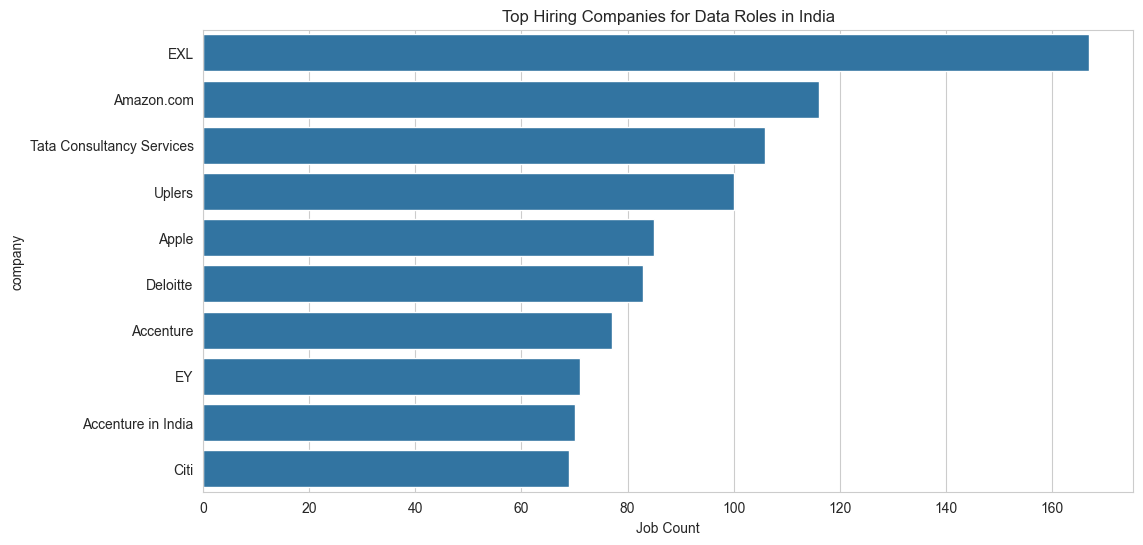

In [281]:
# Top Hiring Companies

top_companies = df['company'].value_counts().head(10)
sns.barplot(y=top_companies.index, x=top_companies.values)
plt.title("Top Hiring Companies for Data Roles in India")
plt.xlabel("Job Count")
plt.show()

In [287]:
# export cleaned dataset
df.to_csv('jobs_cleaned.csv', index=False)
print(f"\n🎉 Feature extraction complete! Dataset ready for EDA and modeling.")


🎉 Feature extraction complete! Dataset ready for EDA and modeling.
